# TABVERSE — Generation Evaluation Analysis
GriTS-based evaluation of table format conversion (inter-format & intra-format).

| Section | Focus |
|---------|-------|
| **1. Primary Tables** | Per-model GriTS-Top and GriTS-Con across all format pairs |
| **2. Format-Pair Heatmap** | Which input→output combination is hardest/easiest |
| **3. Same vs Cross Format** | Same-format (identity) vs cross-format conversion |
| **4. Dataset Analysis** | GriTS scores broken down by dataset |
| **5. Model Leaderboard** | Overall ranking by GriTS-Top and GriTS-Con |

> **Run `python src/evaluation/grits.py` first** to populate `results/scores/generation/`.

In [25]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

matplotlib.rcParams.update({'figure.dpi': 130, 'font.size': 11})
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
def _find_root():
    cwd = Path.cwd()
    for _ in range(6):
        if (cwd / 'results').exists() and (cwd / 'src').exists():
            return cwd
        cwd = cwd.parent
    raise FileNotFoundError('TABVERSE root not found — run from inside the repo')

ROOT          = _find_root()
FINAL_CSV_DIR = ROOT / 'results' / 'scores' / 'generation'
FINAL_CSV_DIR.mkdir(parents=True, exist_ok=True)
print(f'ROOT         : {ROOT}')
print(f'CSV dir      : {FINAL_CSV_DIR}')

FORMATS   = ['html', 'markdown', 'latex']
FMT_SHORT = {'html': 'html', 'markdown': 'md', 'latex': 'ltx'}
DATASETS  = ['wikitq', 'hybridqa', 'sqa', 'tabfact', 'feverous']
PAIRS     = [(i, o) for i in FORMATS for o in FORMATS]
PAIR_LBLS = [f'{FMT_SHORT[i]}->{FMT_SHORT[o]}' for i, o in PAIRS]

ROOT         : /mnt/data1/momina/TABVERSE
CSV dir      : /mnt/data1/momina/TABVERSE/results/final_csv/generation


In [27]:
gen_csv = FINAL_CSV_DIR / 'generation.csv'
if not gen_csv.exists():
    raise FileNotFoundError(f'{gen_csv} not found — run grits.py first.')

df = pd.read_csv(gen_csv)
df['pair'] = df.apply(lambda r: f"{FMT_SHORT[r['input_format']]}->{FMT_SHORT[r['output_format']]}", axis=1)
df['same_format'] = df['input_format'] == df['output_format']

print(f'Rows          : {len(df):,}')
print(f'Models        : {sorted(df["model"].unique())}')
print(f'Pipelines     : {sorted(df["pipeline"].unique())}')
print(f'Datasets      : {sorted(df["dataset"].unique())}')
print(f'Format pairs  : {sorted(df["pair"].unique())}')

Rows          : 583
Models        : ['InternVL3.5-14B', 'InternVL3.5-30B-A3B', 'Qwen3-VL-30B-A3B-Instruct', 'Qwen3-VL-8B-Instruct', 'SmolVLM2-2.2B-Instruct', 'gemini-3-flash-preview', 'gemma_3-12B-IT', 'gemma_3-27B-IT', 'gpt-5.2', 'llava_1.6-vicuna-13B', 'llava_1.6-vicuna-7B', 'ministral_3-14B-Instruct', 'table-llava-v1.5-7b-hf']
Pipelines     : ['VLM']
Datasets      : ['feverous', 'hybridqa', 'sqa', 'tabfact', 'wikitq']
Format pairs  : ['html->html', 'html->ltx', 'html->md', 'ltx->html', 'ltx->ltx', 'ltx->md', 'md->html', 'md->ltx', 'md->md']


---
## 1. Primary Results Tables

Per-model GriTS-Top and GriTS-Con (averaged across all datasets) for each format pair.  
Source: `results/scores/generation/generation_vlm.csv`

In [28]:
wide_csv = FINAL_CSV_DIR / 'generation_vlm.csv'
if wide_csv.exists():
    wide = pd.read_csv(wide_csv)

    top_cols = [c for c in wide.columns if c.endswith('_top') and c != 'OVERALL_top']
    con_cols = [c for c in wide.columns if c.endswith('_con') and c != 'OVERALL_con']

    print('=== GriTS-Top (structural) ===')
    top_tbl = wide[['model'] + top_cols + ['OVERALL_top']].copy()
    top_tbl.columns = ['model'] + [c.replace('_top', '') for c in top_cols] + ['OVERALL']
    num_cols_t = [c for c in top_tbl.columns if c != 'model']
    display(
        top_tbl.style
            .format('{:.3f}', subset=num_cols_t, na_rep='-')
            .background_gradient(axis=None, cmap='YlGnBu', subset=num_cols_t, vmin=0, vmax=1)
            .set_caption('GriTS-Top — structural similarity (0→1)')
            .set_table_styles([{'selector': 'caption',
                                'props': [('font-weight', 'bold'), ('font-size', '13px')]}])
    )

    print('\n=== GriTS-Con (content) ===')
    con_tbl = wide[['model'] + con_cols + ['OVERALL_con']].copy()
    con_tbl.columns = ['model'] + [c.replace('_con', '') for c in con_cols] + ['OVERALL']
    num_cols_c = [c for c in con_tbl.columns if c != 'model']
    display(
        con_tbl.style
            .format('{:.3f}', subset=num_cols_c, na_rep='-')
            .background_gradient(axis=None, cmap='YlOrRd', subset=num_cols_c, vmin=0, vmax=1)
            .set_caption('GriTS-Con — content similarity (0→1)')
            .set_table_styles([{'selector': 'caption',
                                'props': [('font-weight', 'bold'), ('font-size', '13px')]}])
    )
else:
    print(f'[SKIP] {wide_csv} not found — run grits.py first.')

=== GriTS-Top (structural) ===


,model,html->html,html->md,html->ltx,md->html,md->md,md->ltx,ltx->html,ltx->md,ltx->ltx,OVERALL
0,InternVL3.5-14B,0.987,0.988,0.956,0.991,0.985,0.960,0.965,0.971,0.954,0.973
1,InternVL3.5-30B-A3B,0.983,0.989,0.949,0.989,0.987,0.961,0.965,0.969,0.948,0.971
2,Qwen3-VL-30B-A3B-Instruct,0.985,0.992,0.844,0.990,0.997,0.970,0.973,0.978,0.961,0.965
3,Qwen3-VL-8B-Instruct,0.990,0.997,0.954,0.990,0.996,0.969,0.978,0.983,0.967,0.980
4,SmolVLM2-2.2B-Instruct,0.870,0.864,0.806,0.661,0.788,0.783,0.790,0.850,0.565,0.799
5,gemini-3-flash-preview,0.050,0.955,0.645,0.865,0.966,0.510,0.646,0.930,0.578,0.683
6,gemma_3-12B-IT,0.937,0.950,0.907,0.953,0.960,0.922,0.941,0.946,0.905,0.935
7,gemma_3-27B-IT,0.968,0.967,0.938,0.977,0.974,0.945,0.966,0.961,0.938,0.959
8,gpt-5.2,0.981,0.982,0.813,0.984,0.991,0.947,0.978,0.974,0.932,0.953
9,llava_1.6-vicuna-13B,0.661,0.805,0.228,0.623,0.748,0.222,0.649,0.756,0.267,0.551



=== GriTS-Con (content) ===


,model,html->html,html->md,html->ltx,md->html,md->md,md->ltx,ltx->html,ltx->md,ltx->ltx,OVERALL
0,InternVL3.5-14B,0.951,0.941,0.922,0.930,0.930,0.913,0.928,0.915,0.931,0.929
1,InternVL3.5-30B-A3B,0.951,0.944,0.921,0.934,0.938,0.915,0.927,0.918,0.918,0.930
2,Qwen3-VL-30B-A3B-Instruct,0.978,0.979,0.804,0.969,0.985,0.932,0.952,0.950,0.949,0.944
3,Qwen3-VL-8B-Instruct,0.980,0.982,0.923,0.970,0.982,0.931,0.954,0.954,0.946,0.958
4,SmolVLM2-2.2B-Instruct,0.740,0.740,0.688,0.574,0.683,0.677,0.654,0.690,0.466,0.680
5,gemini-3-flash-preview,0.049,0.941,0.640,0.849,0.956,0.505,0.632,0.908,0.573,0.673
6,gemma_3-12B-IT,0.791,0.792,0.758,0.798,0.807,0.768,0.778,0.774,0.752,0.780
7,gemma_3-27B-IT,0.860,0.845,0.822,0.853,0.850,0.813,0.829,0.818,0.814,0.834
8,gpt-5.2,0.967,0.944,0.782,0.956,0.971,0.907,0.942,0.937,0.893,0.922
9,llava_1.6-vicuna-13B,0.458,0.514,0.149,0.452,0.507,0.149,0.458,0.495,0.191,0.375


---
## 2. Format-Pair Difficulty Heatmap

Average GriTS-Top and GriTS-Con across all models, per input→output format combination.  
Reveals which conversions are inherently easier or harder.

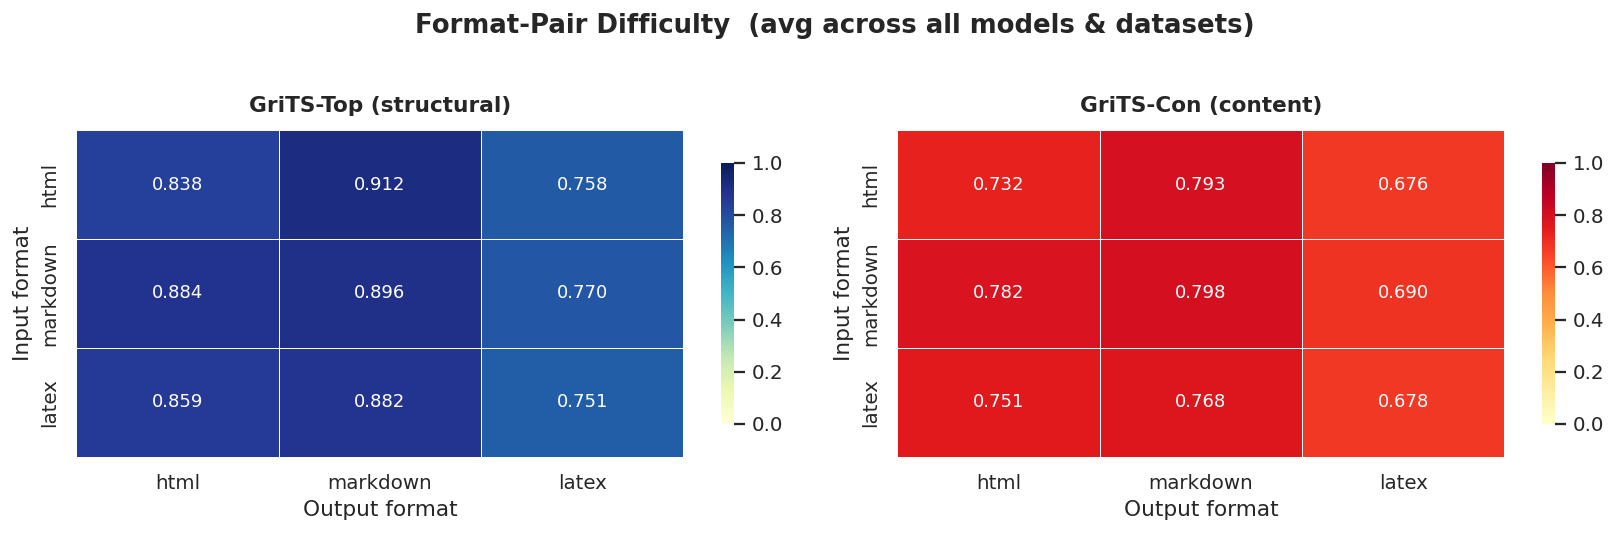

Saved → /mnt/data1/momina/TABVERSE/results/final_csv/generation/fig_format_pair_heatmap.png

Ranking (hardest → easiest by GriTS-Top):


,pair,grits_top,grits_con
0,html→md,0.9122,0.7933
1,md→md,0.8964,0.7982
2,md→html,0.8845,0.7818
3,ltx→md,0.8821,0.7676
4,ltx→html,0.8593,0.7511
5,html→html,0.8379,0.7319
6,md→ltx,0.7704,0.6896
7,html→ltx,0.7584,0.6760
8,ltx→ltx,0.7510,0.6779


In [29]:
pair_avg = (
    df.groupby(['input_format', 'output_format'])[['grits_top', 'grits_con']]
    .mean()
    .reset_index()
)

def to_pivot(metric):
    p = pair_avg.pivot(index='input_format', columns='output_format', values=metric)
    return p.reindex(index=FORMATS, columns=FORMATS)

top_pivot = to_pivot('grits_top')
con_pivot = to_pivot('grits_con')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, pivot, title, cmap in [
    (axes[0], top_pivot, 'GriTS-Top (structural)',  'YlGnBu'),
    (axes[1], con_pivot, 'GriTS-Con (content)',     'YlOrRd'),
]:
    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt='.3f', annot_kws={'size': 10},
        cmap=cmap, vmin=0, vmax=1,
        linewidths=0.5, cbar_kws={'shrink': 0.8},
    )
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Output format')
    ax.set_ylabel('Input format')

plt.suptitle('Format-Pair Difficulty  (avg across all models & datasets)',
             fontweight='bold', y=1.02)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_format_pair_heatmap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

print('\nRanking (hardest → easiest by GriTS-Top):')
pair_rank = (
    pair_avg.assign(pair=lambda r: r['input_format'].map(FMT_SHORT) + '→' + r['output_format'].map(FMT_SHORT))
    [['pair', 'grits_top', 'grits_con']]
    .sort_values('grits_top', ascending=False)
    .reset_index(drop=True)
    .round(4)
)
display(pair_rank)

---
## 3. Same-Format vs Cross-Format Conversion

**Same-format** (identity): model reads table in format X and regenerates in format X.  
**Cross-format**: model converts from format X to format Y (X ≠ Y).  
The gap shows how much quality drops when the output format differs from the input.

Same-format vs Cross-format (gap = same − cross):


,same_top,same_con,cross_top,cross_con,gap_top,gap_con
model,,,,,,
Qwen3-VL-8B-Instruct,0.9881,0.9712,0.9834,0.9569,0.0047,0.0143
Qwen3-VL-30B-A3B-Instruct,0.9846,0.9715,0.9637,0.9362,0.0209,0.0353
InternVL3.5-14B,0.9803,0.9433,0.9775,0.9321,0.0028,0.0112
InternVL3.5-30B-A3B,0.9779,0.9413,0.9767,0.9344,0.0012,0.0069
gpt-5.2,0.9739,0.9487,0.9534,0.9181,0.0205,0.0306
gemma_3-27B-IT,0.9655,0.8504,0.9654,0.8403,0.0001,0.0101
ministral_3-14B-Instruct,0.9577,0.9146,0.9560,0.9028,0.0017,0.0118
gemma_3-12B-IT,0.9406,0.7933,0.9427,0.7884,-0.0021,0.0049
SmolVLM2-2.2B-Instruct,0.7820,0.6665,0.7965,0.6743,-0.0145,-0.0078


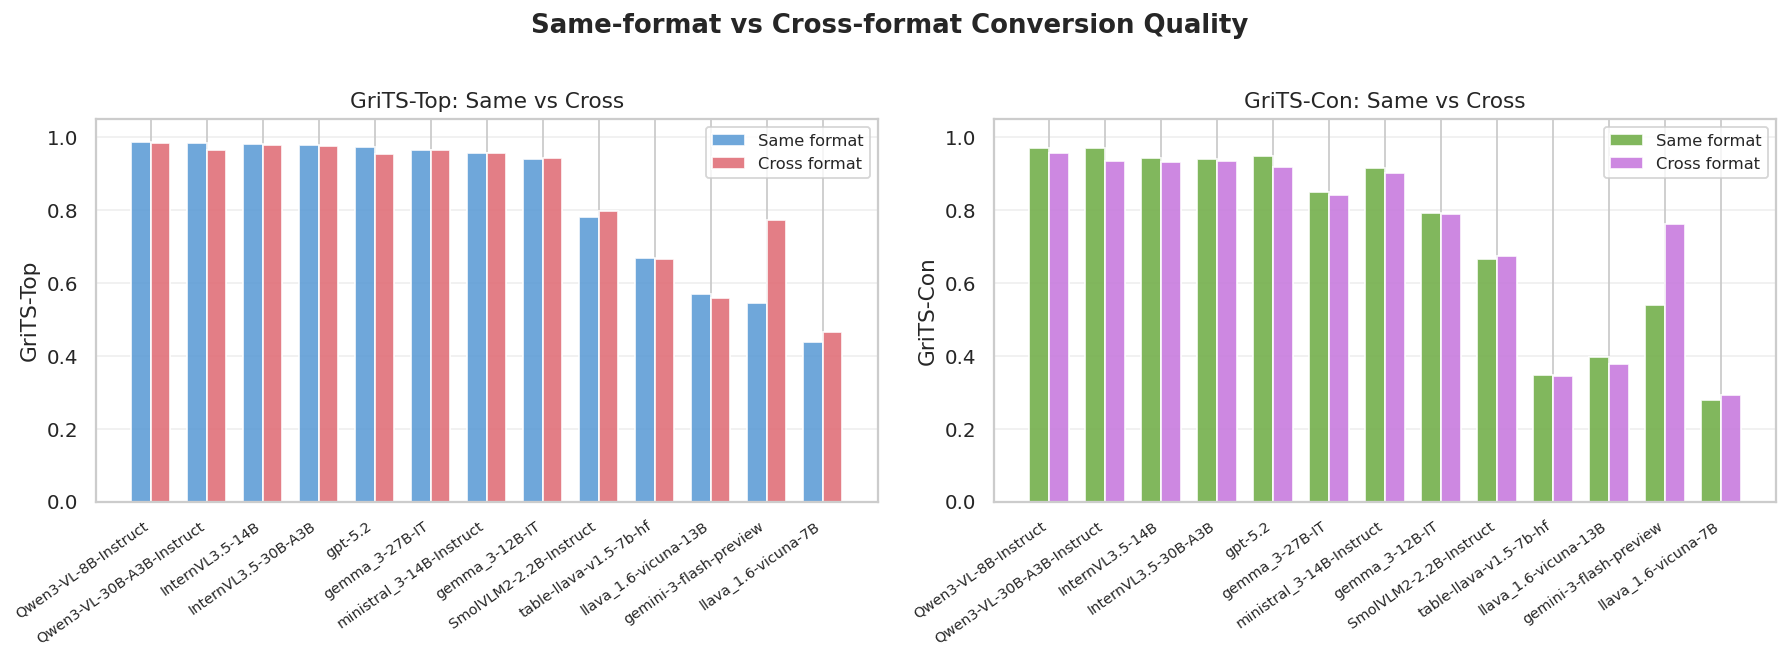

Saved → /mnt/data1/momina/TABVERSE/results/final_csv/generation/fig_same_vs_cross.png


In [30]:
same_avg  = df[df['same_format']].groupby('model')[['grits_top', 'grits_con']].mean().round(4)
cross_avg = df[~df['same_format']].groupby('model')[['grits_top', 'grits_con']].mean().round(4)

comparison = same_avg.rename(columns={'grits_top': 'same_top', 'grits_con': 'same_con'}).join(
    cross_avg.rename(columns={'grits_top': 'cross_top', 'grits_con': 'cross_con'})
).assign(
    gap_top=lambda r: (r['same_top'] - r['cross_top']).round(4),
    gap_con=lambda r: (r['same_con'] - r['cross_con']).round(4),
).sort_values('same_top', ascending=False)

print('Same-format vs Cross-format (gap = same − cross):')
display(comparison)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top_col, cross_col, title, color_s, color_c in [
    (axes[0], 'same_top', 'cross_top', 'GriTS-Top', '#5B9BD5', '#E06C75'),
    (axes[1], 'same_con', 'cross_con', 'GriTS-Con', '#70AD47', '#C678DD'),
]:
    models = comparison.index.tolist()
    x = np.arange(len(models))
    w = 0.35
    ax.bar(x - w/2, comparison[top_col], w, label='Same format', color=color_s, alpha=0.88)
    ax.bar(x + w/2, comparison[cross_col], w, label='Cross format', color=color_c, alpha=0.88)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(title)
    ax.set_title(f'{title}: Same vs Cross')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Same-format vs Cross-format Conversion Quality',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_same_vs_cross.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

### 3b. Per-Format Pair Breakdown per Model

Each subplot shows one model's GriTS-Top across all 9 format pairs (input × output).

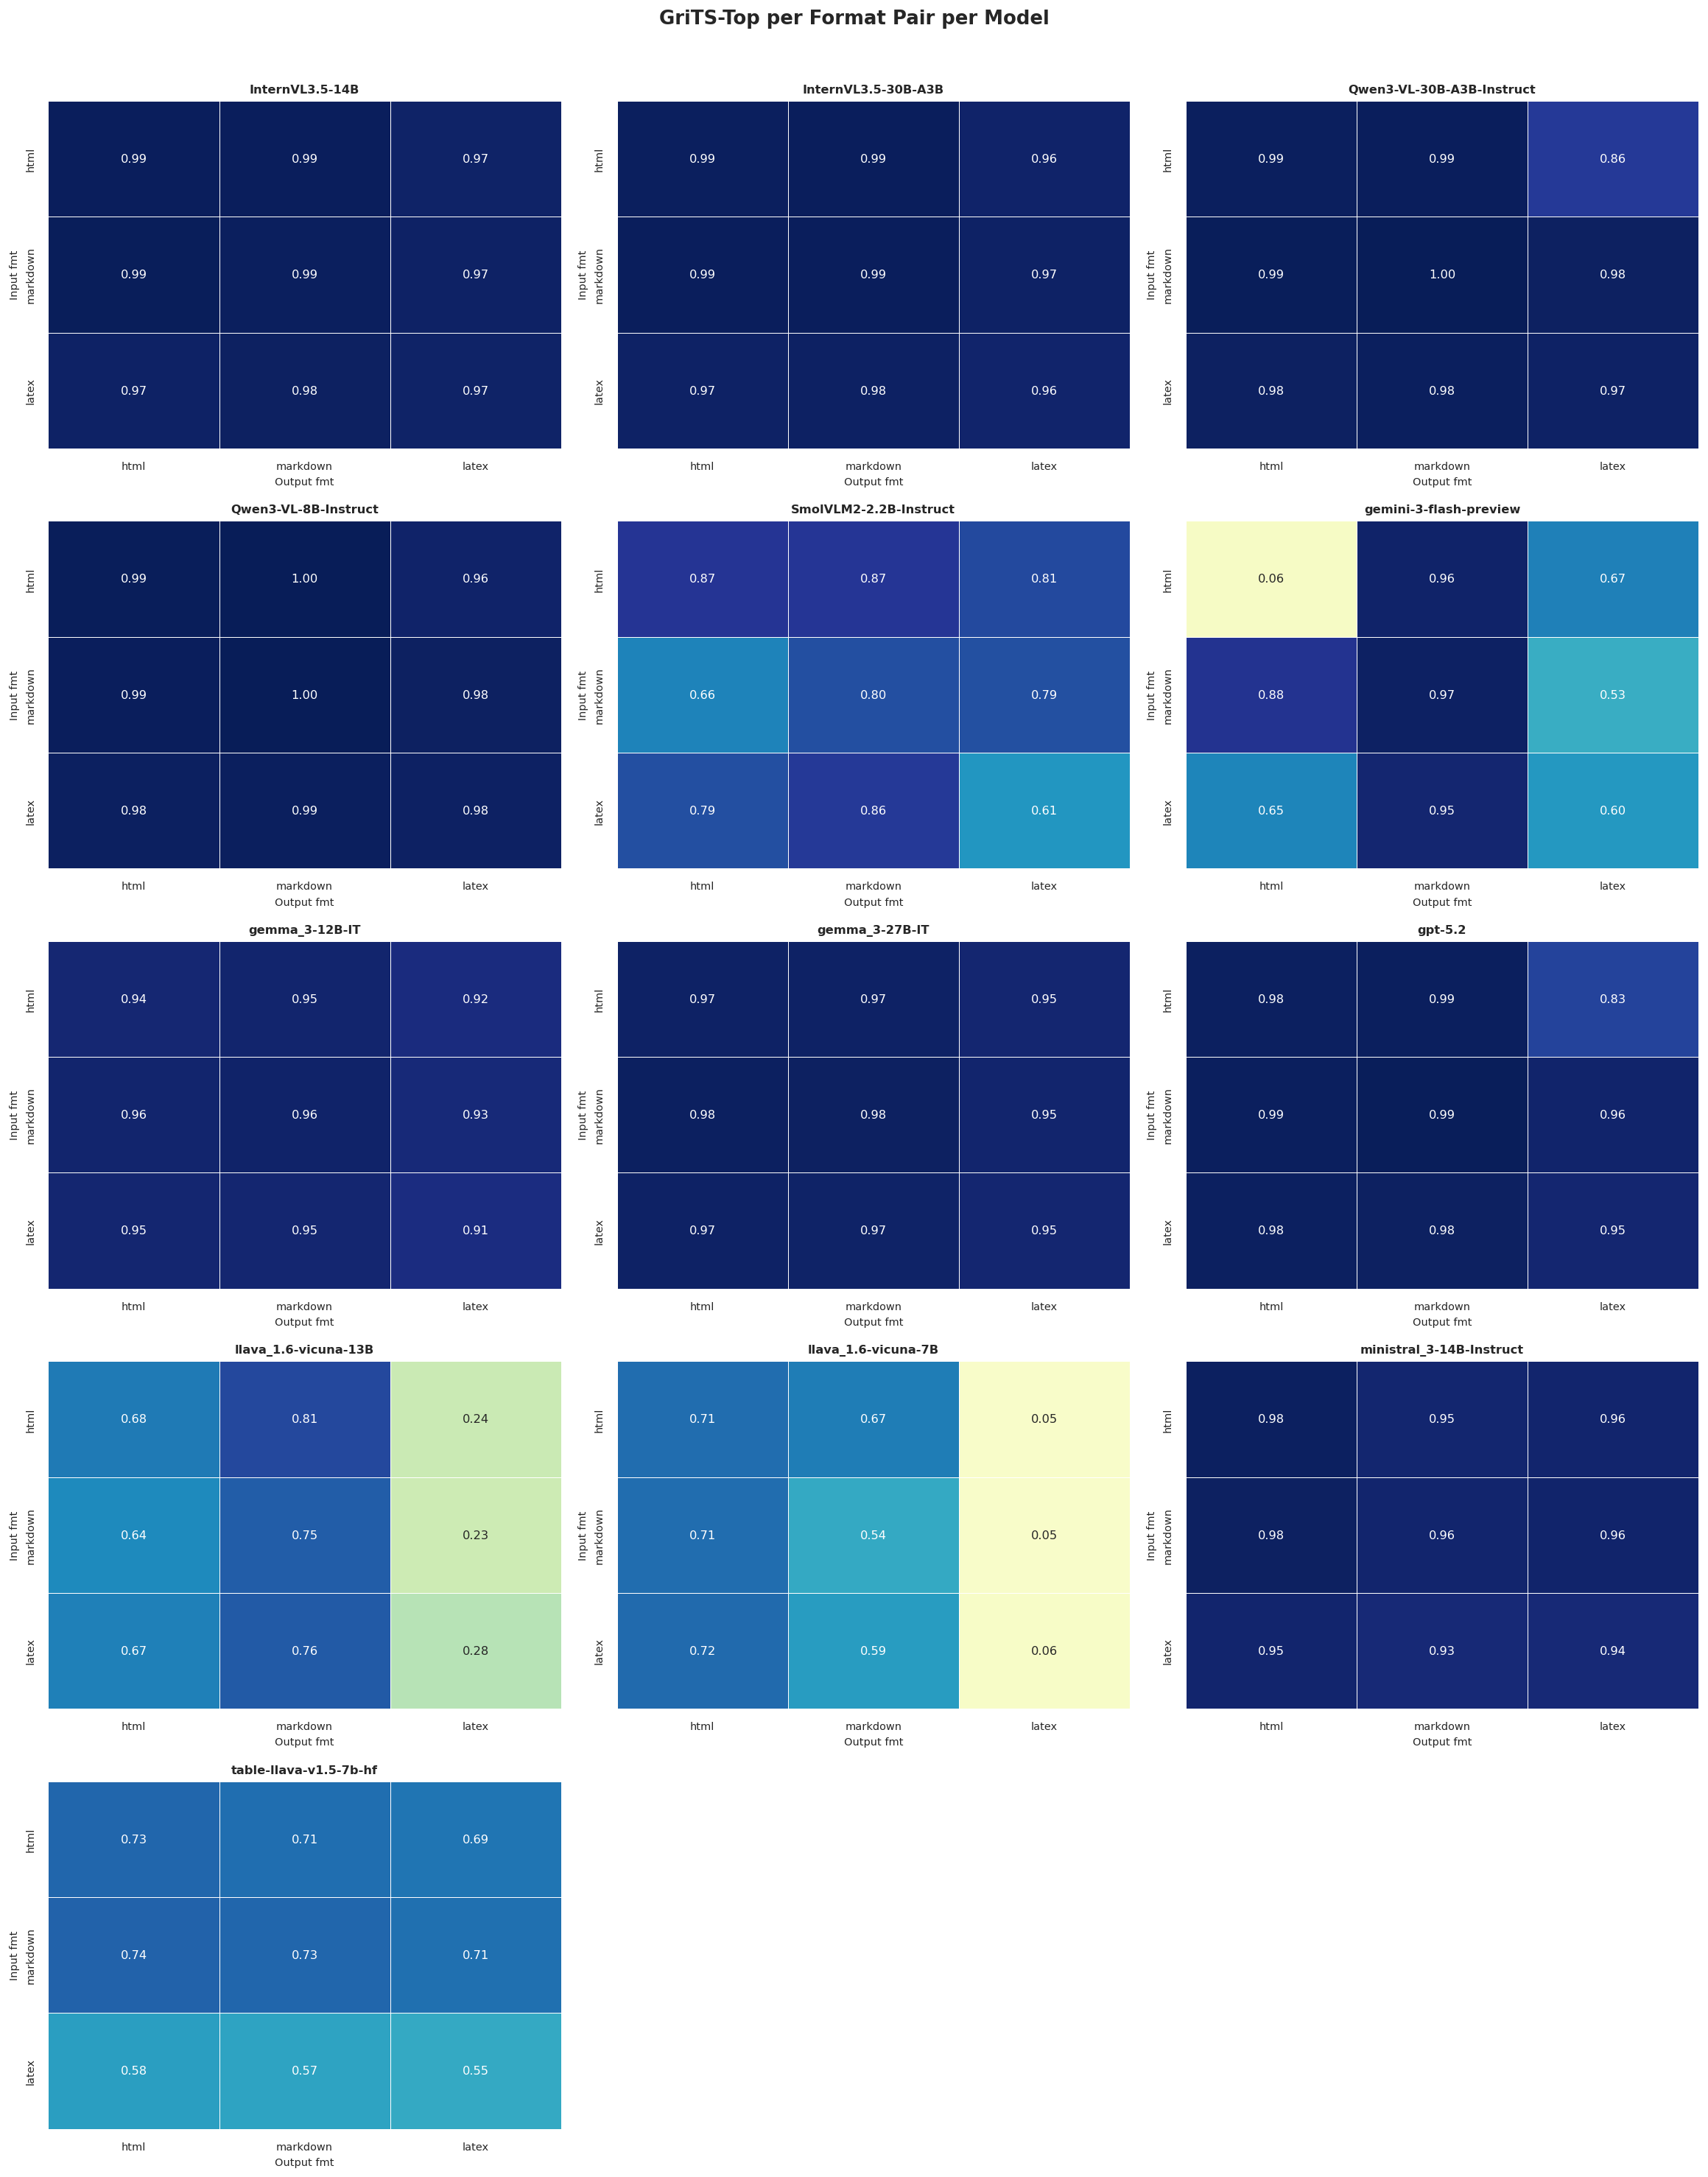

Saved → /mnt/data1/momina/TABVERSE/results/final_csv/generation/fig_per_model_format_heatmap.png


In [31]:
models = sorted(df['model'].unique())
n = len(models)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
axes_flat = axes.flatten() if n > 1 else [axes]

for ax, model in zip(axes_flat, models):
    sub = df[df['model'] == model].groupby(['input_format', 'output_format'])['grits_top'].mean()
    pivot = sub.unstack(level='output_format').reindex(index=FORMATS, columns=FORMATS)
    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt='.2f', annot_kws={'size': 9},
        cmap='YlGnBu', vmin=0, vmax=1,
        linewidths=0.4, cbar=False,
    )
    ax.set_title(model, fontsize=9, fontweight='bold')
    ax.set_xlabel('Output fmt', fontsize=8)
    ax.set_ylabel('Input fmt', fontsize=8)
    ax.tick_params(labelsize=8)

for ax in axes_flat[n:]:
    ax.set_visible(False)

plt.suptitle('GriTS-Top per Format Pair per Model', fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_per_model_format_heatmap.png')
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

---
## 4. Dataset Analysis

Average GriTS-Top and GriTS-Con per dataset (across all format pairs and models).  
Reveals which datasets have more complex tables that are harder to faithfully convert.

Global dataset ranking (avg across all models & format pairs):


,grits_top,grits_con
dataset,,
sqa,0.8669,0.7825
tabfact,0.8656,0.7822
feverous,0.8485,0.7333
hybridqa,0.8474,0.7501
wikitq,0.7680,0.6559


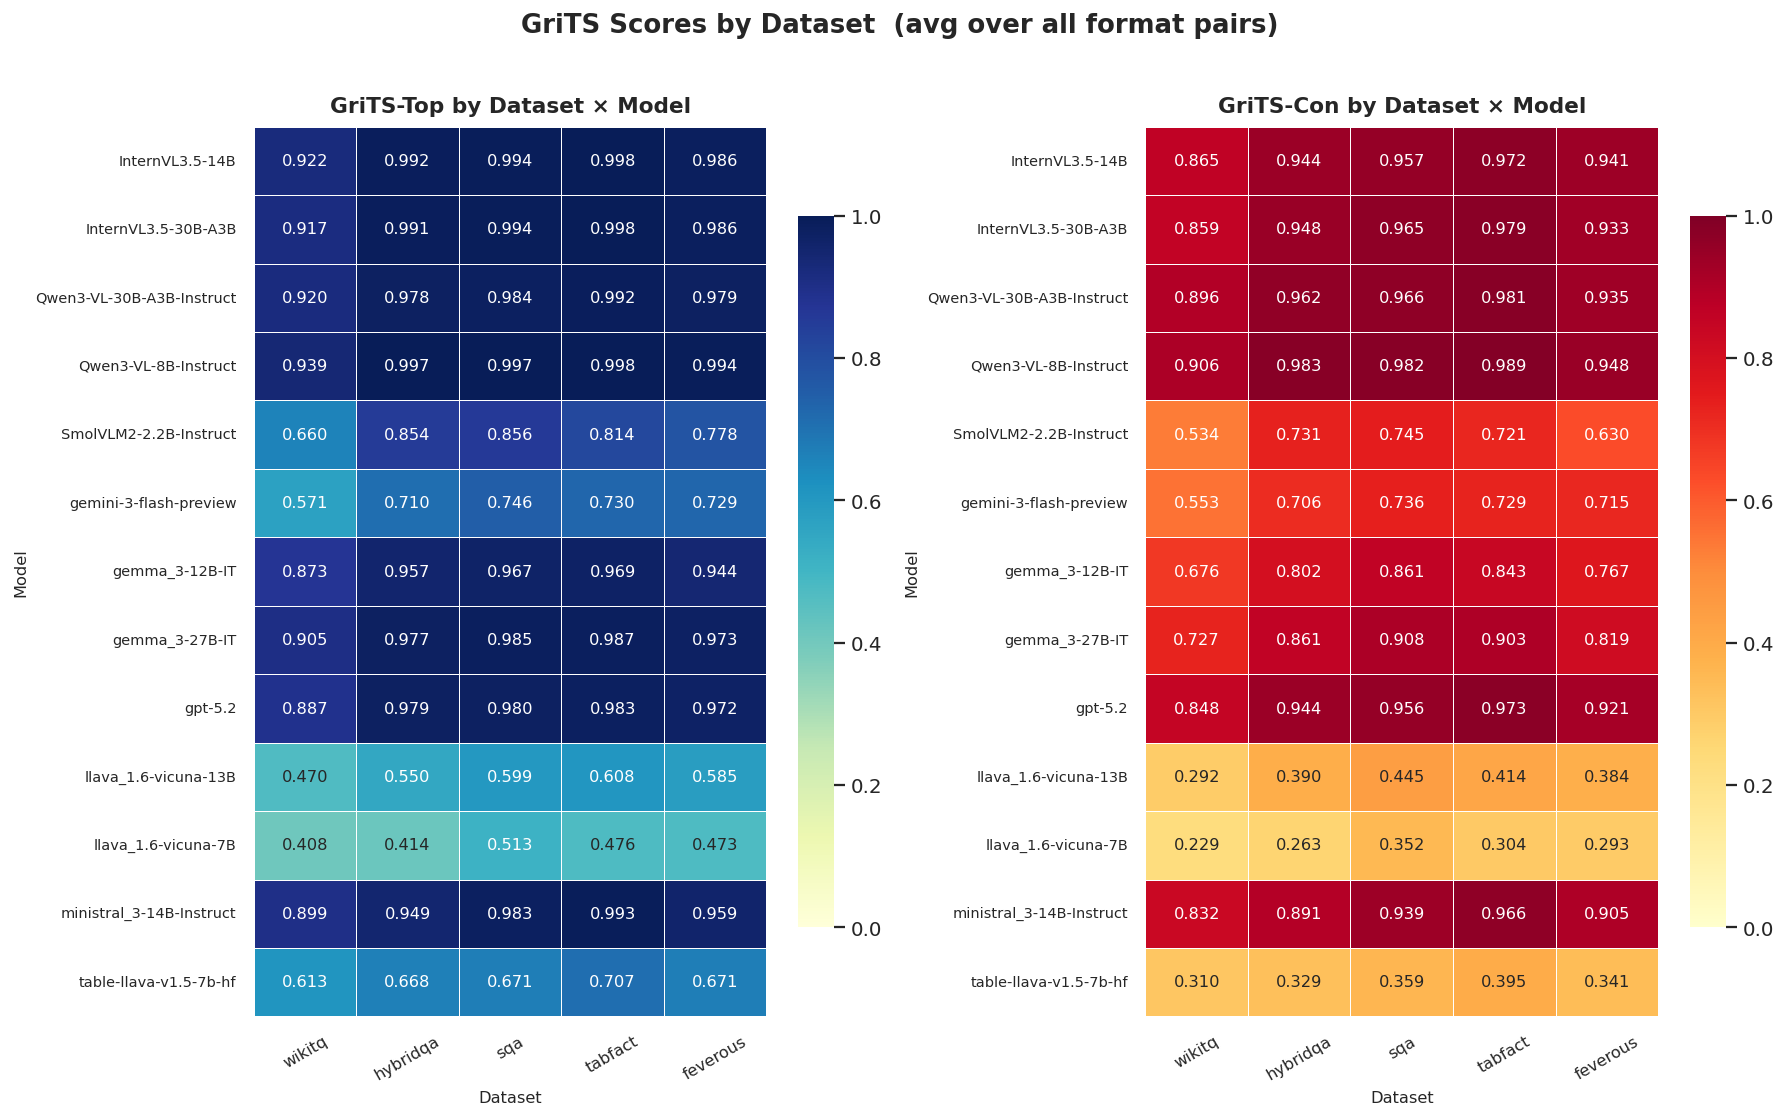

Saved → /mnt/data1/momina/TABVERSE/results/final_csv/generation/fig_dataset_heatmap.png


In [32]:
ds_avg = (
    df.groupby(['dataset', 'model'])[['grits_top', 'grits_con']]
    .mean()
    .reset_index()
)

ds_global = (
    ds_avg.groupby('dataset')[['grits_top', 'grits_con']]
    .mean().round(4)
    .reindex(DATASETS)
    .sort_values('grits_top', ascending=False)
)

print('Global dataset ranking (avg across all models & format pairs):')
display(ds_global)

# Per-model × dataset heatmap
ds_pivot_top = (
    ds_avg.pivot_table(index='model', columns='dataset', values='grits_top')
    .reindex(columns=DATASETS)
)
ds_pivot_con = (
    ds_avg.pivot_table(index='model', columns='dataset', values='grits_con')
    .reindex(columns=DATASETS)
)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(models) * 0.5 + 2)))

for ax, pivot, title, cmap in [
    (axes[0], ds_pivot_top, 'GriTS-Top', 'YlGnBu'),
    (axes[1], ds_pivot_con, 'GriTS-Con', 'YlOrRd'),
]:
    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt='.3f', annot_kws={'size': 9},
        cmap=cmap, vmin=0, vmax=1,
        linewidths=0.5, cbar_kws={'shrink': 0.8},
    )
    ax.set_title(f'{title} by Dataset × Model', fontweight='bold', pad=8)
    ax.set_xlabel('Dataset', fontsize=9)
    ax.set_ylabel('Model', fontsize=9)
    ax.tick_params(axis='x', labelsize=9, rotation=30)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

plt.suptitle('GriTS Scores by Dataset  (avg over all format pairs)',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_dataset_heatmap.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

In [33]:
ds_save = (
    df.groupby(['model', 'dataset'])[['grits_top', 'grits_con']]
    .mean().round(4).reset_index()
)
ds_out = FINAL_CSV_DIR / 'generation_dataset.csv'
ds_save.to_csv(ds_out, index=False)
print(f'Saved → {ds_out}')

Saved → /mnt/data1/momina/TABVERSE/results/final_csv/generation/generation_dataset.csv


---
## 5. Model Leaderboard

Overall GriTS-Top and GriTS-Con averaged across all format pairs and all datasets.  
Also breaks down by same-format (identity) vs cross-format performance.

Model Leaderboard (sorted by overall GriTS-Top):


,model,overall_top,overall_con,same_top,same_con,cross_top,cross_con
0,Qwen3-VL-8B-Instruct,0.9850,0.9617,0.9881,0.9712,0.9834,0.9569
1,InternVL3.5-14B,0.9784,0.9359,0.9803,0.9433,0.9775,0.9321
2,InternVL3.5-30B-A3B,0.9771,0.9367,0.9779,0.9413,0.9767,0.9344
3,Qwen3-VL-30B-A3B-Instruct,0.9707,0.9480,0.9846,0.9715,0.9637,0.9362
4,gemma_3-27B-IT,0.9654,0.8437,0.9655,0.8504,0.9654,0.8403
5,gpt-5.2,0.9602,0.9283,0.9739,0.9487,0.9534,0.9181
6,ministral_3-14B-Instruct,0.9566,0.9067,0.9577,0.9146,0.9560,0.9028
7,gemma_3-12B-IT,0.9420,0.7900,0.9406,0.7933,0.9427,0.7884
8,SmolVLM2-2.2B-Instruct,0.7921,0.6719,0.7820,0.6665,0.7965,0.6743
9,gemini-3-flash-preview,0.6975,0.6877,0.5466,0.5413,0.7730,0.7608


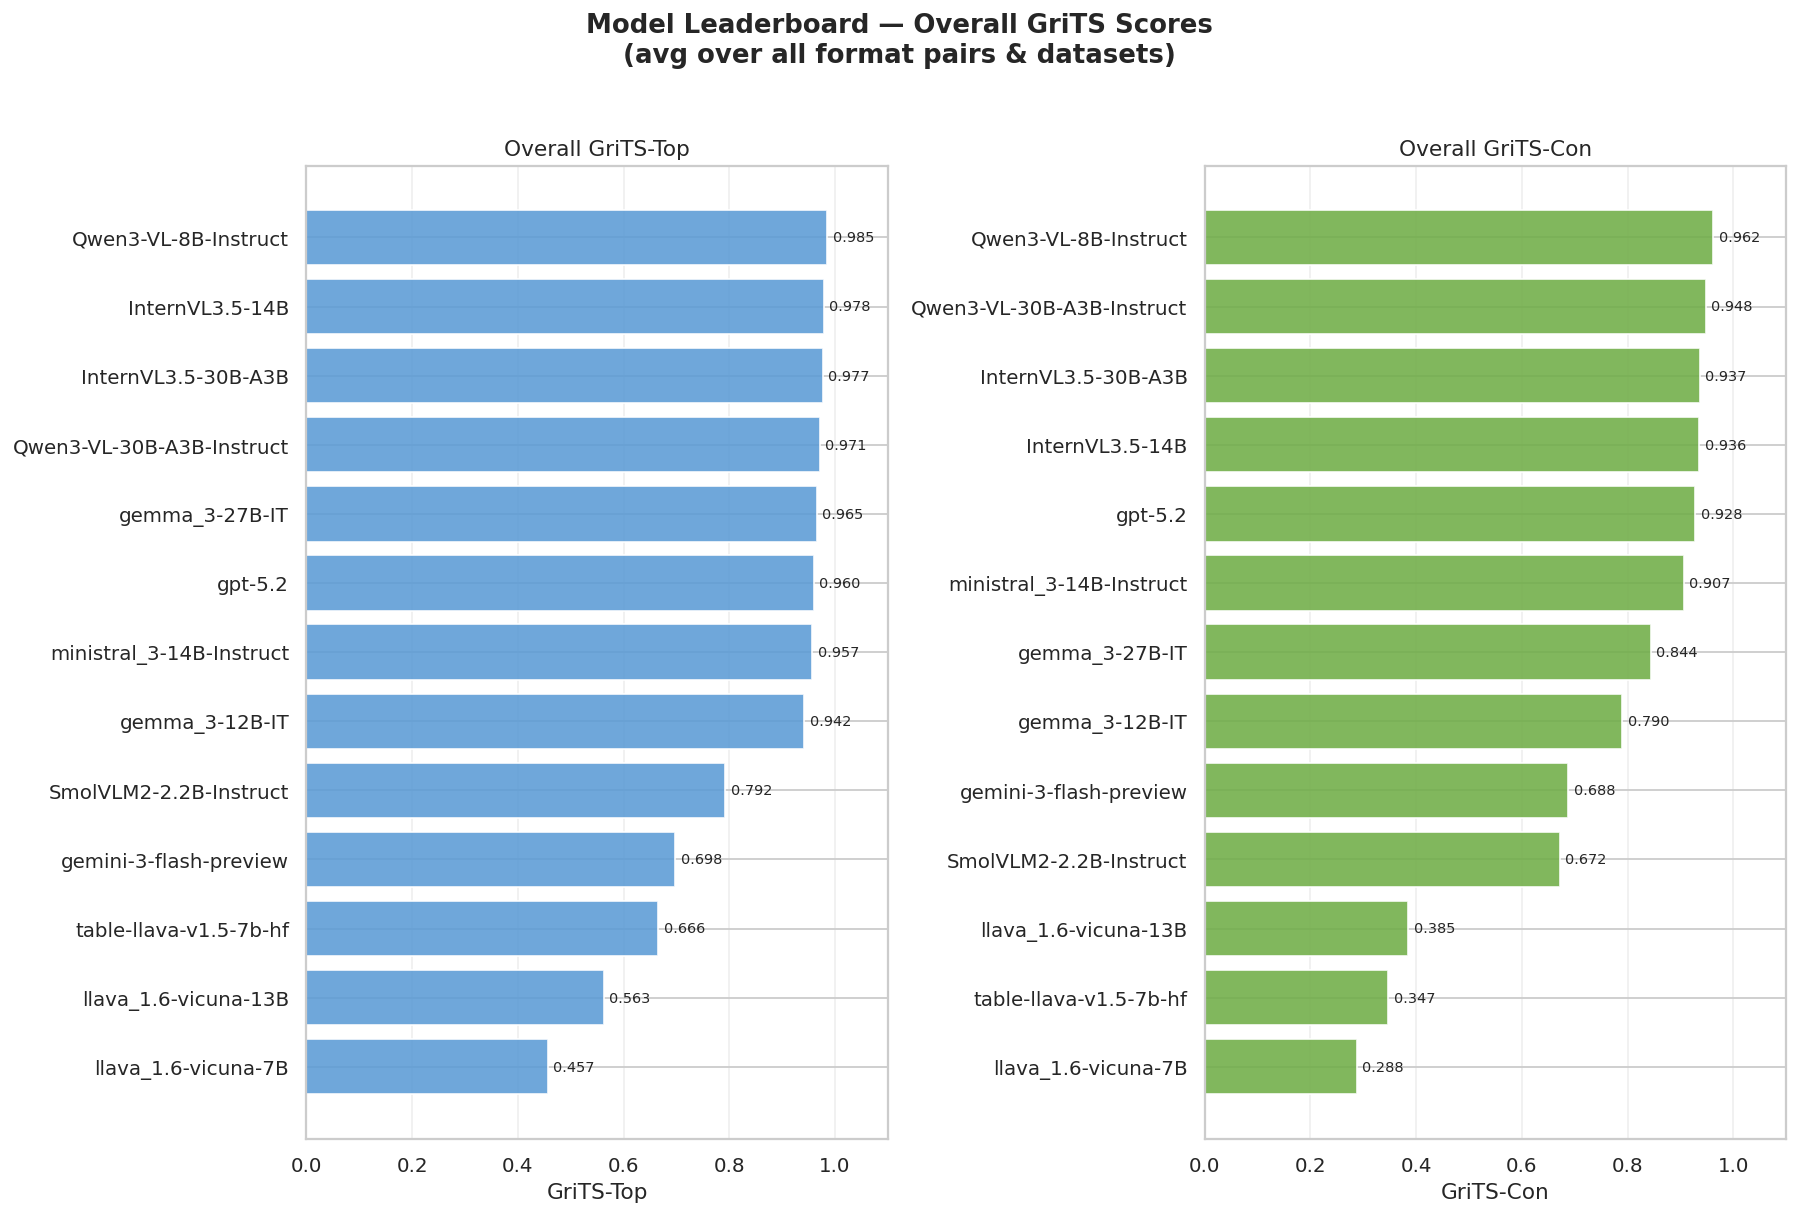

Saved → /mnt/data1/momina/TABVERSE/results/final_csv/generation/fig_leaderboard.png


In [34]:
overall = (
    df.groupby('model')[['grits_top', 'grits_con']]
    .mean().round(4)
    .sort_values('grits_top', ascending=False)
    .rename(columns={'grits_top': 'overall_top', 'grits_con': 'overall_con'})
)

same_ov  = (df[df['same_format']]
            .groupby('model')[['grits_top', 'grits_con']]
            .mean().round(4)
            .rename(columns={'grits_top': 'same_top', 'grits_con': 'same_con'}))

cross_ov = (df[~df['same_format']]
            .groupby('model')[['grits_top', 'grits_con']]
            .mean().round(4)
            .rename(columns={'grits_top': 'cross_top', 'grits_con': 'cross_con'}))

leaderboard = overall.join(same_ov).join(cross_ov).reset_index()
print('Model Leaderboard (sorted by overall GriTS-Top):')
display(leaderboard)

# Horizontal bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(leaderboard) * 0.55 + 2)))

for ax, col, title, color in [
    (axes[0], 'overall_top', 'GriTS-Top', '#5B9BD5'),
    (axes[1], 'overall_con', 'GriTS-Con', '#70AD47'),
]:
    sub = leaderboard.sort_values(col)
    bars = ax.barh(sub['model'], sub[col], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=8)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel(title)
    ax.set_title(f'Overall {title}')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Leaderboard — Overall GriTS Scores\n(avg over all format pairs & datasets)',
             fontweight='bold', y=1.02)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_leaderboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

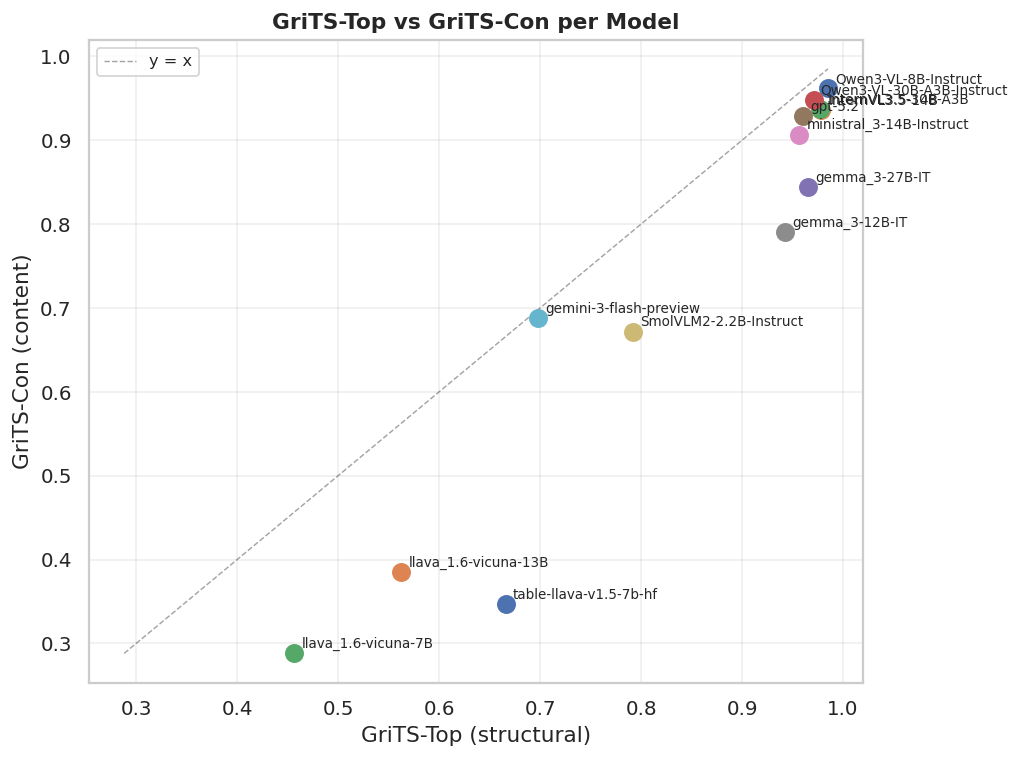

Saved → /mnt/data1/momina/TABVERSE/results/final_csv/generation/fig_top_vs_con_scatter.png


In [35]:
# GriTS-Top vs GriTS-Con scatter: reveals whether models with good structure
# also have good content fidelity
fig, ax = plt.subplots(figsize=(8, 6))
for _, row in leaderboard.iterrows():
    ax.scatter(row['overall_top'], row['overall_con'], s=90, zorder=3)
    ax.annotate(row['model'], (row['overall_top'], row['overall_con']),
                fontsize=7.5, textcoords='offset points', xytext=(4, 3))

# diagonal y=x reference
mn = min(leaderboard[['overall_top', 'overall_con']].min())
mx = max(leaderboard[['overall_top', 'overall_con']].max())
ax.plot([mn, mx], [mn, mx], 'k--', linewidth=0.8, alpha=0.4, label='y = x')
ax.set_xlabel('GriTS-Top (structural)')
ax.set_ylabel('GriTS-Con (content)')
ax.set_title('GriTS-Top vs GriTS-Con per Model', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path = str(FINAL_CSV_DIR / 'fig_top_vs_con_scatter.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

In [36]:
lb_out = FINAL_CSV_DIR / 'generation_leaderboard.csv'
leaderboard.to_csv(lb_out, index=False)
print(f'Saved → {lb_out}')

Saved → /mnt/data1/momina/TABVERSE/results/final_csv/generation/generation_leaderboard.csv
